   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 19.9 MB/s eta 0:00:00
Loading TweetEval Sentiment Dataset...


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

...

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset loaded successfully!

Dataset Shape: (59899, 2)


,Text,sentiment
0,"""QT @user In the original draft of the 7th boo...",Positive
1,"""Ben Smith / Smith (concussion) remains out of...",Neutral
2,Sorry bout the stream last night I crashed out...,Neutral
3,Chase Headley's RBI double in the 8th inning o...,Neutral
4,@user Alciato: Bee will invest 150 million in ...,Positive



Missing Values:
Text         0
sentiment    0
dtype: int64

Duplicate Rows:
26


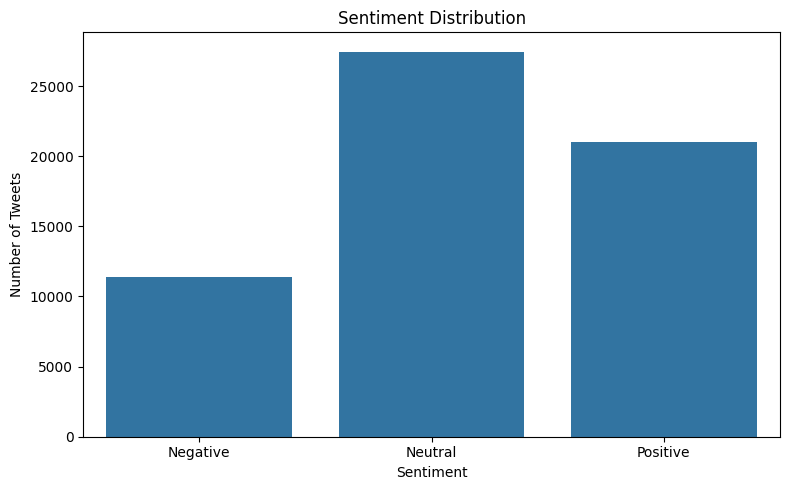


Preprocessing...
Preprocessing completed!

Training: 47896
Testing : 11975

Creating TF-IDF...
TF-IDF completed!
Training shape: (47896, 15000)
Testing shape : (11975, 15000)

Training Naive Bayes...
Naive Bayes completed!

Training Logistic Regression...
Logistic Regression completed!

Naive Bayes
Accuracy : 0.6184
Precision: 0.6223
Recall   : 0.6184
F1 Score : 0.6064

Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.31      0.42      2275
     Neutral       0.60      0.74      0.66      5493
    Positive       0.65      0.63      0.64      4207

    accuracy                           0.62     11975
   macro avg       0.63      0.56      0.57     11975
weighted avg       0.62      0.62      0.61     11975


Logistic Regression
Accuracy : 0.6552
Precision: 0.6592
Recall   : 0.6552
F1 Score : 0.6494

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.43      0.52      2

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.618372,0.622305,0.618372,0.606375
1,Logistic Regression,0.655198,0.659186,0.655198,0.649424


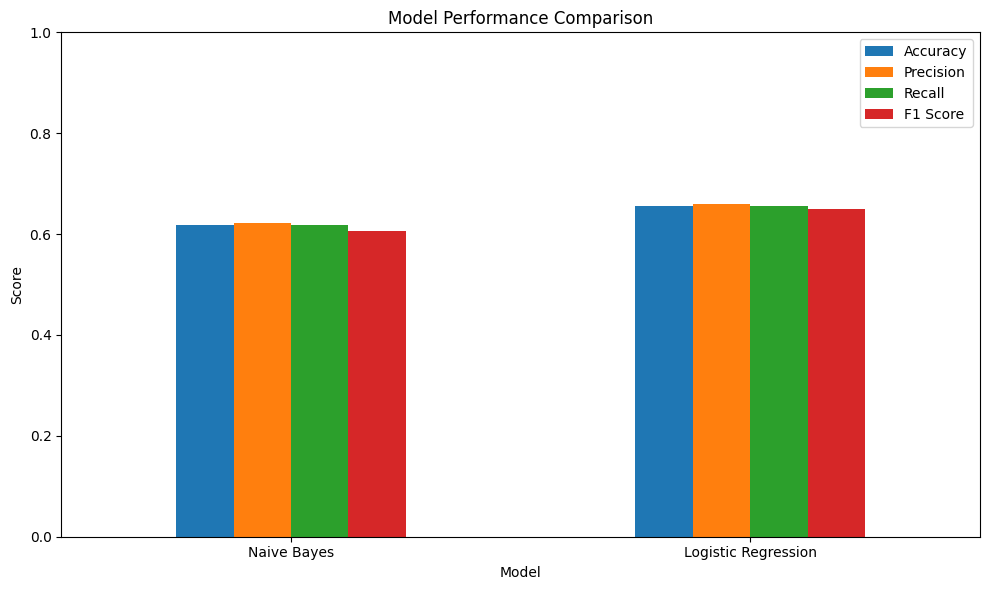

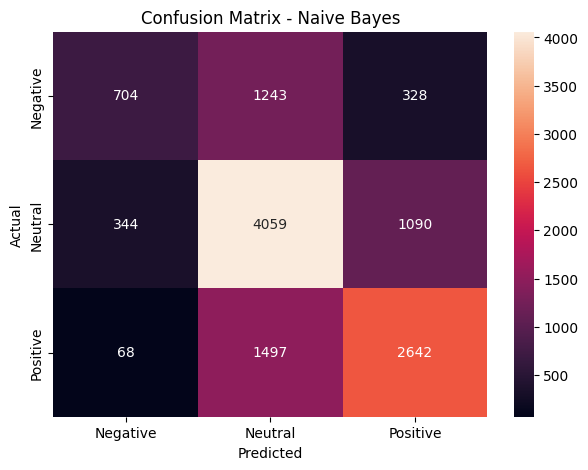

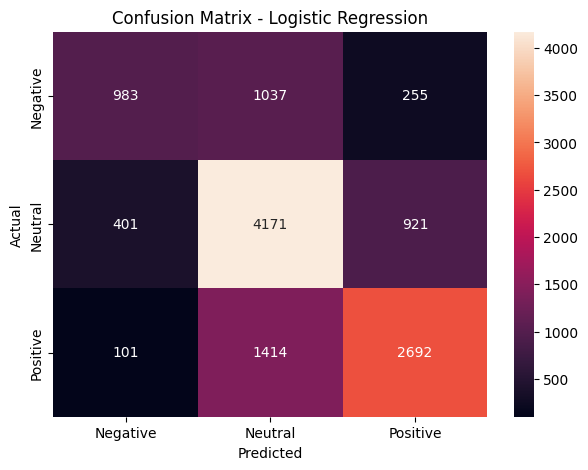

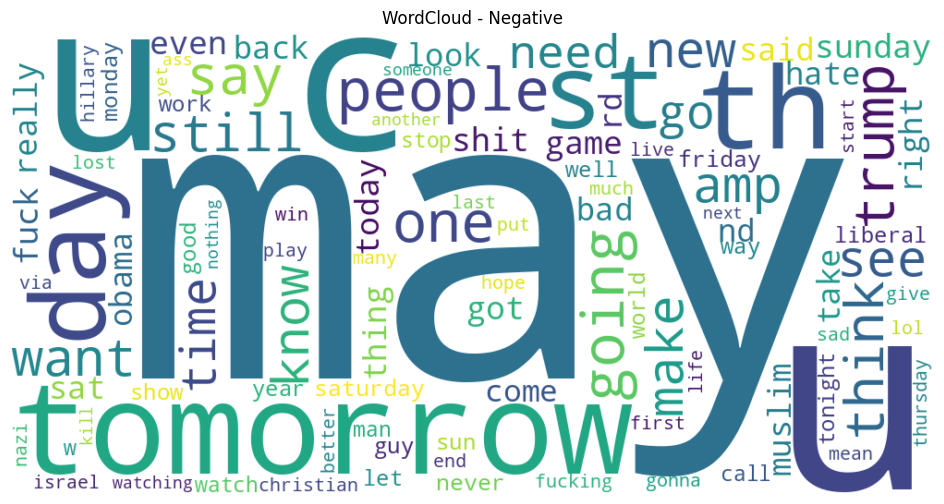

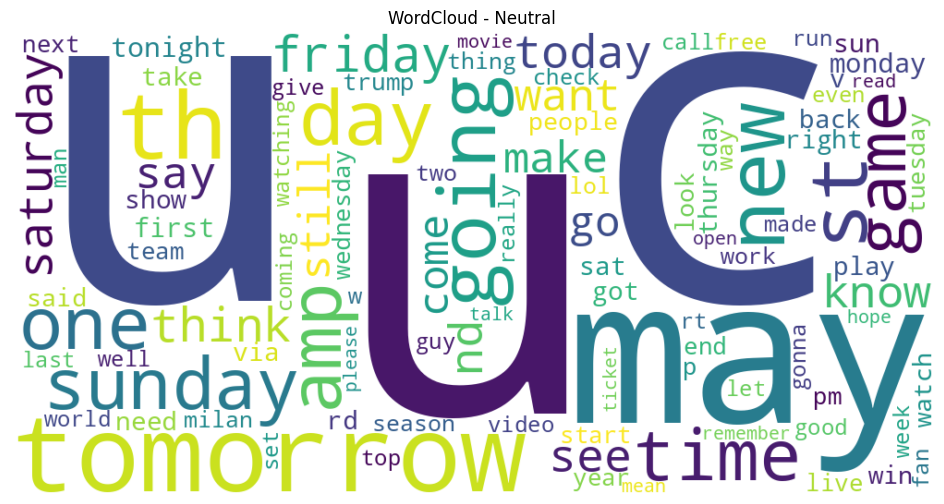

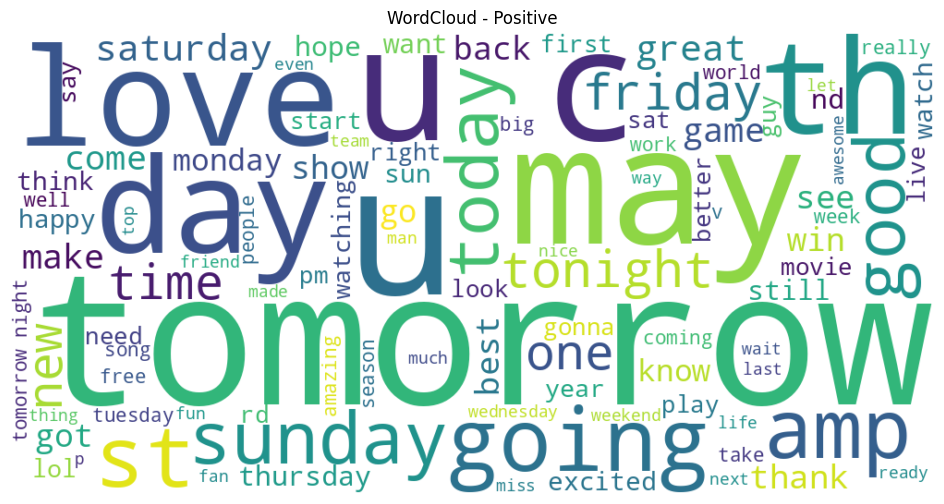


Total Misclassified: 4129

Five Misclassified Examples:


,Text,Actual,Predicted
4,going helsinki tomorrow day tomorrow yay,Neutral,Positive
6,suspect rbi may next line either going rate cu...,Negative,Neutral
7,local teams c amp w irrigation amp phe chitral...,Neutral,Positive
8,eid sat amp bajrangibhaijaan salman khan film ...,Neutral,Positive
11,cnn weeps erstwhile hero fidel castro,Negative,Neutral



BEST MODEL
Model: Logistic Regression
Accuracy: 0.6552
F1 Score: 0.6494

TASK 4 - SENTIMENT ANALYSIS COMPLETED

Sentiment analysis was performed on Twitter data containing
Negative, Neutral and Positive sentiments.

Text preprocessing included:
- Lowercase conversion
- URL removal
- Mention removal
- Hashtag removal
- Punctuation removal
- Stopword removal

TF-IDF was used for feature extraction.

Two machine learning models were trained:
1. Naive Bayes
2. Logistic Regression

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

WordClouds were created for all three sentiment classes.

Five misclassified examples were analyzed.

The model with the highest F1 Score was selected as the
best-performing model.

Real-world applications include:
- Customer feedback analysis
- Product review analysis
- Social media monitoring
- Brand monitoring
- Customer service improvement



In [ ]:
# ============================================================
# OASIS INFOBYTE - TASK 4 SENTIMENT ANALYSIS
# ============================================================

!pip -q install -U datasets wordcloud seaborn

import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud


# ============================================================
# 1. LOAD DATASET
# ============================================================

print("Loading TweetEval Sentiment Dataset...")

dataset = load_dataset(
    "cardiffnlp/tweet_eval",
    "sentiment"
)

print("Dataset loaded successfully!")


# ============================================================
# 2. COMBINE TRAIN + VALIDATION + TEST
# ============================================================

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

df = df.rename(
    columns={"text": "Text"}
)

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df["sentiment"] = df["label"].map(label_map)

df = df[["Text", "sentiment"]]

print("\nDataset Shape:", df.shape)

display(df.head())


# ============================================================
# 3. DATA CLEANING
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)


# ============================================================
# 4. SENTIMENT DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="sentiment",
    order=["Negative","Neutral","Positive"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()


# ============================================================
# 5. TEXT PREPROCESSING
# ============================================================

stop_words = set(
    stopwords.words("english")
)

def preprocess_text(text):

    text = text.lower()

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    text = re.sub(
        r"@\w+",
        "",
        text
    )

    text = re.sub(
        r"#",
        "",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


print("\nPreprocessing...")

df["clean_text"] = df["Text"].apply(
    preprocess_text
)

df = df[
    df["clean_text"].str.strip() != ""
]

df = df.reset_index(drop=True)

print("Preprocessing completed!")


# ============================================================
# 6. TRAIN TEST SPLIT 80/20
# ============================================================

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining:", len(X_train))
print("Testing :", len(X_test))


# ============================================================
# 7. TF-IDF
# ============================================================

print("\nCreating TF-IDF...")

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape :", X_test_tfidf.shape)


# ============================================================
# 8. NAIVE BAYES
# ============================================================

print("\nTraining Naive Bayes...")

nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

print("Naive Bayes completed!")


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================

print("\nTraining Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

print("Logistic Regression completed!")


# ============================================================
# 10. EVALUATION
# ============================================================

def evaluate(name, actual, predicted):

    acc = accuracy_score(
        actual,
        predicted
    )

    precision = precision_score(
        actual,
        predicted,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        actual,
        predicted,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        actual,
        predicted,
        average="weighted",
        zero_division=0
    )

    print("\n================================")
    print(name)
    print("================================")

    print("Accuracy :", round(acc,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report:")

    print(
        classification_report(
            actual,
            predicted,
            zero_division=0
        )
    )

    return [
        name,
        acc,
        precision,
        recall,
        f1
    ]


nb_result = evaluate(
    "Naive Bayes",
    y_test,
    nb_pred
)

lr_result = evaluate(
    "Logistic Regression",
    y_test,
    lr_pred
)


# ============================================================
# 11. MODEL COMPARISON
# ============================================================

results = pd.DataFrame(
    [nb_result, lr_result],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\nMODEL COMPARISON")

display(results)


# ============================================================
# 12. COMPARISON GRAPH
# ============================================================

results.set_index(
    "Model"
)[
    ["Accuracy","Precision","Recall","F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 13. CONFUSION MATRICES
# ============================================================

labels = [
    "Negative",
    "Neutral",
    "Positive"
]

cm_nb = confusion_matrix(
    y_test,
    nb_pred,
    labels=labels
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix - Naive Bayes"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


cm_lr = confusion_matrix(
    y_test,
    lr_pred,
    labels=labels
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# 14. WORDCLOUDS
# ============================================================

for sentiment in [
    "Negative",
    "Neutral",
    "Positive"
]:

    text = " ".join(
        df[
            df["sentiment"] == sentiment
        ]["clean_text"]
    )

    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12,6))

    plt.imshow(
        wc,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "WordCloud - " + sentiment
    )

    plt.show()


# ============================================================
# 15. ERROR ANALYSIS
# ============================================================

error_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": lr_pred
})

errors = error_df[
    error_df["Actual"] !=
    error_df["Predicted"]
]

print(
    "\nTotal Misclassified:",
    len(errors)
)

print(
    "\nFive Misclassified Examples:"
)

display(
    errors.head(5)
)


# ============================================================
# 16. BEST MODEL
# ============================================================

best = results.loc[
    results["F1 Score"].idxmax()
]

print("\n==============================")
print("BEST MODEL")
print("==============================")

print(
    "Model:",
    best["Model"]
)

print(
    "Accuracy:",
    round(best["Accuracy"],4)
)

print(
    "F1 Score:",
    round(best["F1 Score"],4)
)


# ============================================================
# 17. SAVE OUTPUTS
# ============================================================

df.to_csv(
    "sentiment_cleaned_dataset.csv",
    index=False
)

results.to_csv(
    "sentiment_model_results.csv",
    index=False
)

errors.head(20).to_csv(
    "sentiment_error_analysis.csv",
    index=False
)


# ============================================================
# 18. FINAL CONCLUSION
# ============================================================

print("""
============================================================
TASK 4 - SENTIMENT ANALYSIS COMPLETED
============================================================

Sentiment analysis was performed on Twitter data containing
Negative, Neutral and Positive sentiments.

Text preprocessing included:
- Lowercase conversion
- URL removal
- Mention removal
- Hashtag removal
- Punctuation removal
- Stopword removal

TF-IDF was used for feature extraction.

Two machine learning models were trained:
1. Naive Bayes
2. Logistic Regression

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

WordClouds were created for all three sentiment classes.

Five misclassified examples were analyzed.

The model with the highest F1 Score was selected as the
best-performing model.

Real-world applications include:
- Customer feedback analysis
- Product review analysis
- Social media monitoring
- Brand monitoring
- Customer service improvement
============================================================
""")